In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [51]:
# Load processed dataset
df = pd.read_csv("../data/processed/cpi_oni.csv")

df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .reset_index(drop=True)
)

# Test period
TEST_SIZE = 24

test_dates = (
    df.iloc[-TEST_SIZE:]["date"]
      .reset_index(drop=True)
)

y_train = df.iloc[:-TEST_SIZE]["food_inflation"].values

print(
    "Test period:",
    test_dates.min(),
    "to",
    test_dates.max()
)

Test period: 2024-01-01 00:00:00 to 2025-12-01 00:00:00


In [52]:
# ---------------- ARIMAX ----------------

arimax = pd.read_csv(
    "../data/processed/arimax_predictions.csv"
)

# ARIMAX CSV does not preserve the original dates,
# so assign the confirmed 24 test dates.
arimax["date"] = test_dates.values

arimax = arimax.rename(columns={
    "actual_food_inflation": "actual",
    "predicted_food_inflation": "arimax"
})

arimax = arimax[[
    "date",
    "actual",
    "arimax"
]]


# ---------------- Prophet ----------------

prophet = pd.read_csv(
    "../data/processed/prophet_predictions.csv"
)

prophet = prophet.rename(columns={
    "ds": "date",
    "predicted_food_inflation": "prophet"
})

prophet["date"] = pd.to_datetime(
    prophet["date"]
)

prophet = prophet[[
    "date",
    "prophet"
]]


# ---------------- LSTM + ONI ----------------

lstm = pd.read_csv(
    "../data/processed/lstm_predictions.csv"
)

lstm = lstm.rename(columns={
    "predicted_food_inflation": "lstm_oni"
})

lstm["date"] = pd.to_datetime(
    lstm["date"]
)

lstm = lstm[[
    "date",
    "lstm_oni"
]]


# ---------------- LSTM Baseline ----------------

baseline = pd.read_csv(
    "../data/processed/lstm_baseline_predictions.csv"
)

baseline = baseline.rename(columns={
    "predicted_food_inflation": "lstm_baseline"
})

baseline["date"] = pd.to_datetime(
    baseline["date"]
)

baseline = baseline[[
    "date",
    "lstm_baseline"
]]

In [53]:
# Merge all four models

comparison = arimax.merge(
    prophet,
    on="date",
    how="inner"
)

comparison = comparison.merge(
    lstm,
    on="date",
    how="inner"
)

comparison = comparison.merge(
    baseline,
    on="date",
    how="inner"
)

comparison = (
    comparison
    .sort_values("date")
    .reset_index(drop=True)
)

display(comparison)

print("Shape:", comparison.shape)

print("\nDate range:")
print(
    comparison["date"].min(),
    "to",
    comparison["date"].max()
)

print("\nMissing values:")
print(comparison.isna().sum())

,date,actual,arimax,prophet,lstm_oni,lstm_baseline
0,2024-01-01,8.30,9.272413,3.494633,9.593246,9.557168
1,2024-02-01,8.66,8.944435,3.064483,9.981662,8.105743
2,2024-03-01,8.52,8.870764,3.371879,10.302421,8.814161
3,2024-04-01,8.70,8.921603,3.606333,10.541404,8.572158
4,2024-05-01,8.69,8.985986,3.774561,10.702701,8.701096
5,2024-06-01,9.36,9.031746,4.063045,10.784204,8.471540
6,2024-07-01,5.42,9.067350,4.647844,10.792333,9.053225
7,2024-08-01,5.66,9.080946,4.603095,10.296307,4.940202
8,2024-09-01,9.24,9.096234,4.381226,9.817428,6.066242
9,2024-10-01,10.87,9.103058,4.433706,9.698999,9.684754


Shape: (24, 6)

Date range:
2024-01-01 00:00:00 to 2025-12-01 00:00:00

Missing values:
date             0
actual           0
arimax           0
prophet          0
lstm_oni         0
lstm_baseline    0
dtype: int64


In [54]:
#Creating Metric functions

def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denominator == 0,0,np.abs(y_true - y_pred) / denominator)) * 100


def mase(y_true, y_pred, y_train):
    # Naive one-step forecast errors on training data
    naive_errors = np.abs(np.diff(y_train))

    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan

    return np.mean(np.abs(y_true - y_pred)) / scale

In [55]:
#Preparing actual and training values

y_true = comparison["actual"].values

# Training-period food inflation for MASE
y_train = df.iloc[:-TEST_SIZE]["food_inflation"].values


#Calculating metrics for each model

models = {
    "ARIMAX": comparison["arimax"].values,
    "Prophet": comparison["prophet"].values,
    "LSTM + ONI": comparison["lstm_oni"].values
}

results = []

for model_name, y_pred in models.items():

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    smape_value = smape(y_true, y_pred)

    mase_value = mase(
        y_true,
        y_pred,
        y_train
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "MASE": mase_value
    })

metrics_df = pd.DataFrame(results)

display(metrics_df)

,Model,MAE,RMSE,sMAPE (%),MASE
0,ARIMAX,5.116283,6.968454,86.691679,3.802225
1,Prophet,4.524748,5.100074,103.685090,3.362619
2,LSTM + ONI,4.201831,4.984564,90.559779,3.122639


In [56]:
# Load LSTM baseline predictions

baseline = pd.read_csv(
    "../data/processed/lstm_baseline_predictions.csv"
)

display(baseline.head())
print("Baseline shape:", baseline.shape)

,date,actual_food_inflation,predicted_food_inflation
0,2024-01-01,8.30,9.557168
1,2024-02-01,8.66,8.105743
2,2024-03-01,8.52,8.814161
3,2024-04-01,8.70,8.572158
4,2024-05-01,8.69,8.701096


Baseline shape: (24, 3)


In [57]:
#Standardize baseline columns

baseline = baseline.rename(columns={
    "predicted_food_inflation": "lstm_baseline"
})

baseline["date"] = pd.to_datetime(baseline["date"])

baseline = baseline[["date", "lstm_baseline"]]

display(baseline.head())

,date,lstm_baseline
0,2024-01-01,9.557168
1,2024-02-01,8.105743
2,2024-03-01,8.814161
3,2024-04-01,8.572158
4,2024-05-01,8.701096


In [58]:
# Remove duplicate baseline columns from the existing comparison

comparison = comparison.drop(
    columns=[
        "lstm_baseline",
        "lstm_baseline_x",
        "lstm_baseline_y"
    ],
    errors="ignore"
)

# Make sure baseline has the correct structure
baseline = baseline[[
    "date",
    "lstm_baseline"
]]

# Merge baseline again
comparison = comparison.merge(
    baseline,
    on="date",
    how="inner"
)

comparison = (
    comparison
    .sort_values("date")
    .reset_index(drop=True)
)

print("Shape:", comparison.shape)
print("\nColumns:")
print(comparison.columns.tolist())

print("\nMissing values:")
print(comparison.isna().sum())

display(comparison.head())

Shape: (24, 6)

Columns:
['date', 'actual', 'arimax', 'prophet', 'lstm_oni', 'lstm_baseline']

Missing values:
date             0
actual           0
arimax           0
prophet          0
lstm_oni         0
lstm_baseline    0
dtype: int64


,date,actual,arimax,prophet,lstm_oni,lstm_baseline
0,2024-01-01,8.30,9.272413,3.494633,9.593246,9.557168
1,2024-02-01,8.66,8.944435,3.064483,9.981662,8.105743
2,2024-03-01,8.52,8.870764,3.371879,10.302421,8.814161
3,2024-04-01,8.70,8.921603,3.606333,10.541404,8.572158
4,2024-05-01,8.69,8.985986,3.774561,10.702701,8.701096


In [59]:
print("Shape:", comparison.shape)
print("\nMissing values:")
print(comparison.isna().sum())

Shape: (24, 6)

Missing values:
date             0
actual           0
arimax           0
prophet          0
lstm_oni         0
lstm_baseline    0
dtype: int64


In [60]:
def smape(y_true, y_pred):
    denominator = (
        np.abs(y_true) +
        np.abs(y_pred)
    ) / 2

    return np.mean(
        np.where(
            denominator == 0,
            0,
            np.abs(y_true - y_pred) / denominator
        )
    ) * 100


def mase(y_true, y_pred, y_train):
    # Naive one-step errors on training data
    naive_errors = np.abs(
        np.diff(y_train)
    )

    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan

    return (
        np.mean(np.abs(y_true - y_pred))
        / scale
    )

In [61]:
# Calculate metrics for all models

# Actual test values
y_true = comparison["actual"].values

# Load training data again for MASE
df_metrics = pd.read_csv(
    "../data/processed/cpi_oni.csv"
)

df_metrics["date"] = pd.to_datetime(
    df_metrics["date"]
)

df_metrics = (
    df_metrics
    .sort_values("date")
    .reset_index(drop=True)
)

TEST_SIZE = 24

y_train = df_metrics.iloc[:-TEST_SIZE]["food_inflation"].values


# Metric functions
def smape(y_true, y_pred):
    denominator = (
        np.abs(y_true) + np.abs(y_pred)
    ) / 2

    return np.mean(
        np.where(
            denominator == 0,
            0,
            np.abs(y_true - y_pred) / denominator
        )
    ) * 100


def mase(y_true, y_pred, y_train):
    naive_errors = np.abs(
        np.diff(y_train)
    )

    scale = np.mean(naive_errors)

    if scale == 0:
        return np.nan

    return (
        np.mean(np.abs(y_true - y_pred))
        / scale
    )


# Models to evaluate
models = {
    "ARIMAX": comparison["arimax"].values,
    "Prophet": comparison["prophet"].values,
    "LSTM + ONI": comparison["lstm_oni"].values,
    "LSTM Baseline": comparison["lstm_baseline"].values
}


# Calculate metrics
results = []

for model_name, y_pred in models.items():

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    smape_value = smape(
        y_true,
        y_pred
    )

    mase_value = mase(
        y_true,
        y_pred,
        y_train
    )

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "MASE": mase_value
    })


metrics_df = pd.DataFrame(results)

display(metrics_df)

,Model,MAE,RMSE,sMAPE (%),MASE
0,ARIMAX,5.116283,6.968454,86.691679,3.802225
1,Prophet,4.524748,5.100074,103.685090,3.362619
2,LSTM + ONI,4.201831,4.984564,90.559779,3.122639
3,LSTM Baseline,1.316956,1.658211,44.185169,0.978711


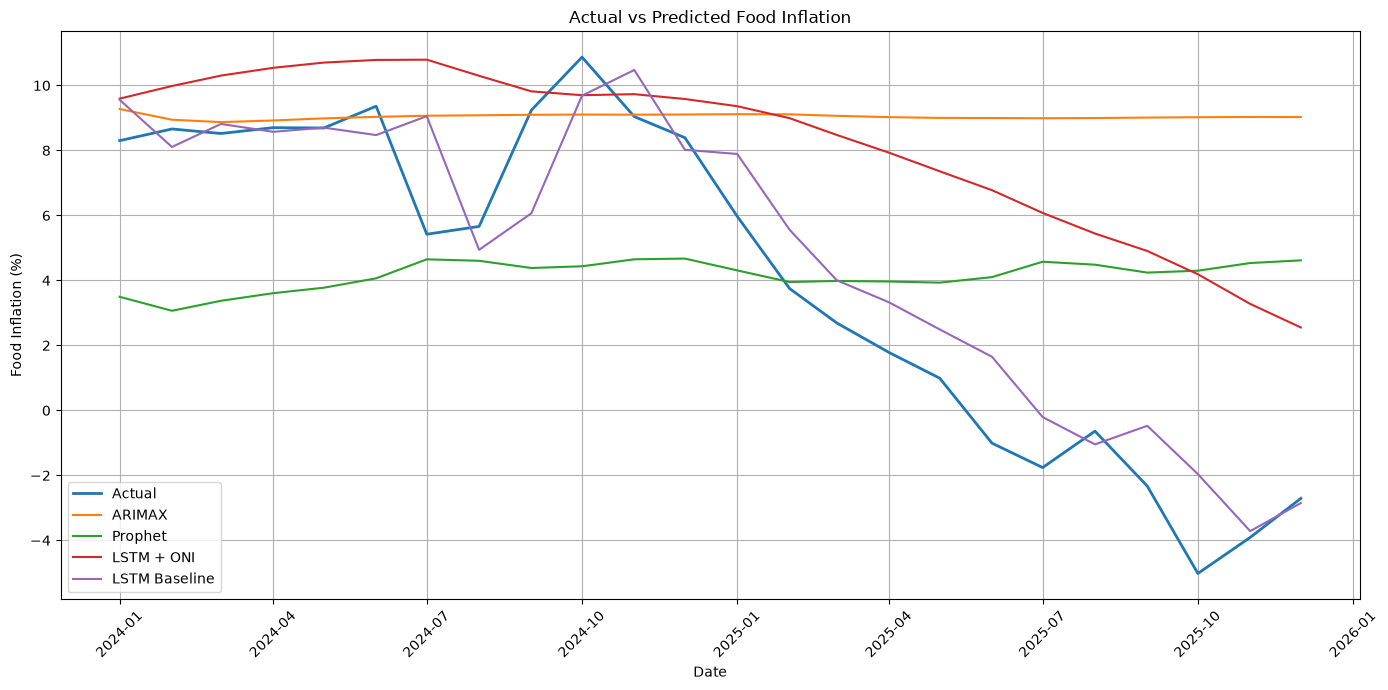

In [62]:
#Actual vs predicted food inflation

plt.figure(figsize=(14, 7))

plt.plot(
    comparison["date"],
    comparison["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison["date"],
    comparison["arimax"],
    label="ARIMAX"
)

plt.plot(
    comparison["date"],
    comparison["prophet"],
    label="Prophet"
)

plt.plot(
    comparison["date"],
    comparison["lstm_oni"],
    label="LSTM + ONI"
)

plt.plot(
    comparison["date"],
    comparison["lstm_baseline"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Food Inflation (%)")
plt.title("Actual vs Predicted Food Inflation")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

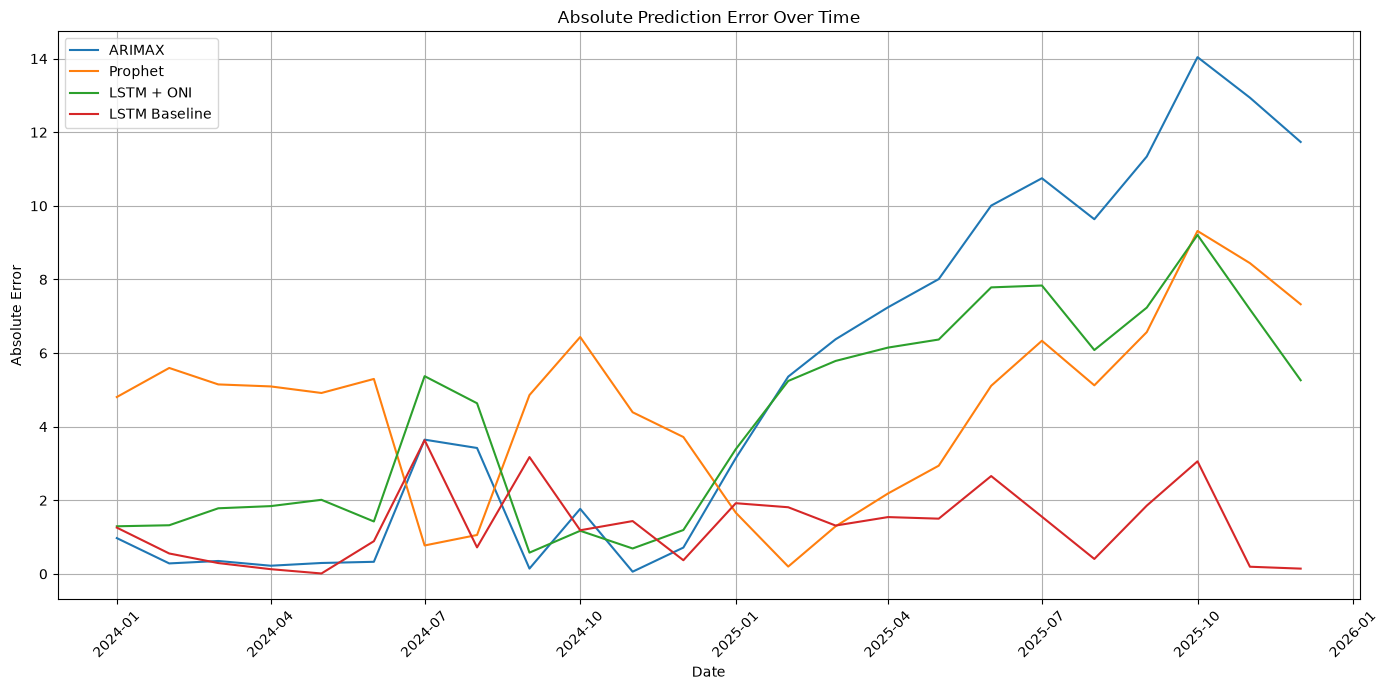

In [63]:
# Calculate absolute errors

comparison["ARIMAX_error"] = np.abs(
    comparison["actual"] - comparison["arimax"]
)

comparison["Prophet_error"] = np.abs(
    comparison["actual"] - comparison["prophet"]
)

comparison["LSTM_ONI_error"] = np.abs(
    comparison["actual"] - comparison["lstm_oni"]
)

comparison["LSTM_baseline_error"] = np.abs(
    comparison["actual"] - comparison["lstm_baseline"]
)
plt.figure(figsize=(14, 7))

plt.plot(
    comparison["date"],
    comparison["ARIMAX_error"],
    label="ARIMAX"
)

plt.plot(
    comparison["date"],
    comparison["Prophet_error"],
    label="Prophet"
)

plt.plot(
    comparison["date"],
    comparison["LSTM_ONI_error"],
    label="LSTM + ONI"
)

plt.plot(
    comparison["date"],
    comparison["LSTM_baseline_error"],
    label="LSTM Baseline"
)

plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.title("Absolute Prediction Error Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

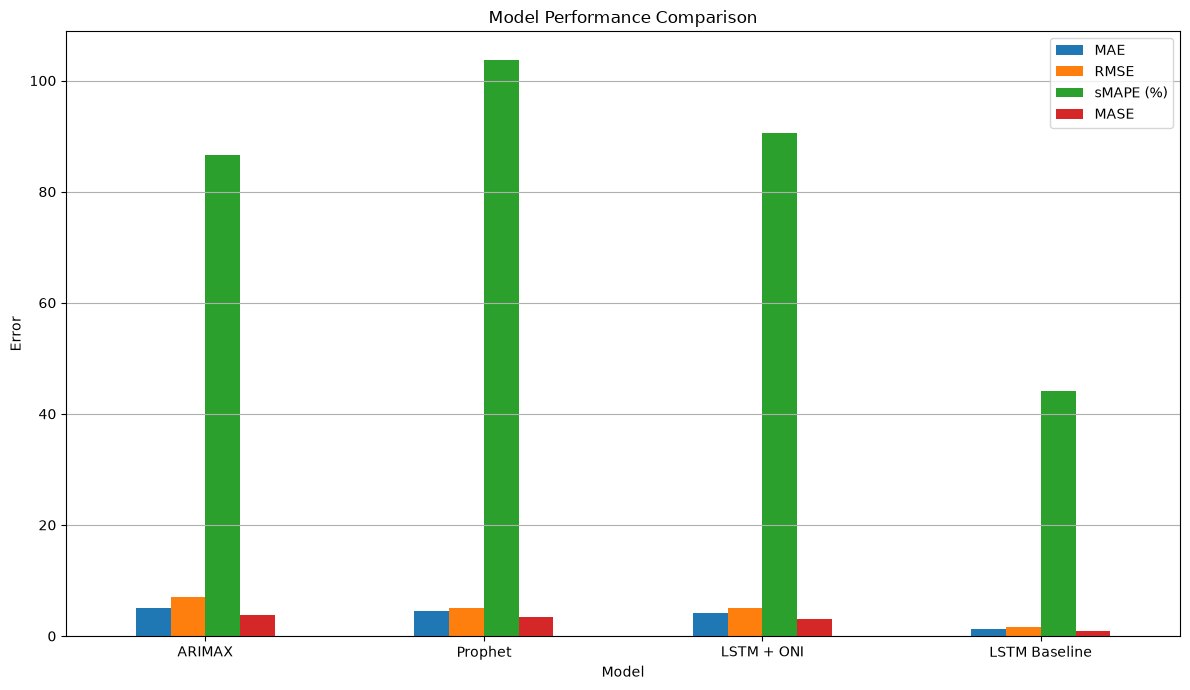

In [64]:
#Metric comparison

metrics_plot = metrics_df.set_index("Model")

metrics_plot[["MAE", "RMSE", "sMAPE (%)", "MASE"]].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.tight_layout()

plt.show()

In [65]:
#Rank models for each evaluation metric
#Lower error = better model

ranking = metrics_df.copy()

for metric in ["MAE", "RMSE", "sMAPE (%)", "MASE"]:
    ranking[f"{metric} Rank"] = ranking[metric].rank(
        ascending=True,
        method="min"
    ).astype(int)

display(ranking)

,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE (%) Rank,MASE Rank
0,ARIMAX,5.116283,6.968454,86.691679,3.802225,4,4,2,4
1,Prophet,4.524748,5.100074,103.685090,3.362619,3,3,4,3
2,LSTM + ONI,4.201831,4.984564,90.559779,3.122639,2,2,3,2
3,LSTM Baseline,1.316956,1.658211,44.185169,0.978711,1,1,1,1


In [66]:
#Calculate average rank across all metrics

ranking["Average Rank"] = ranking[
    ["MAE Rank", "RMSE Rank", "sMAPE (%) Rank", "MASE Rank"]
].mean(axis=1)

ranking = ranking.sort_values("Average Rank")

display(ranking)

,Model,MAE,RMSE,sMAPE (%),MASE,MAE Rank,RMSE Rank,sMAPE (%) Rank,MASE Rank,Average Rank
3,LSTM Baseline,1.316956,1.658211,44.185169,0.978711,1,1,1,1,1.00
2,LSTM + ONI,4.201831,4.984564,90.559779,3.122639,2,2,3,2,2.25
1,Prophet,4.524748,5.100074,103.685090,3.362619,3,3,4,3,3.25
0,ARIMAX,5.116283,6.968454,86.691679,3.802225,4,4,2,4,3.50


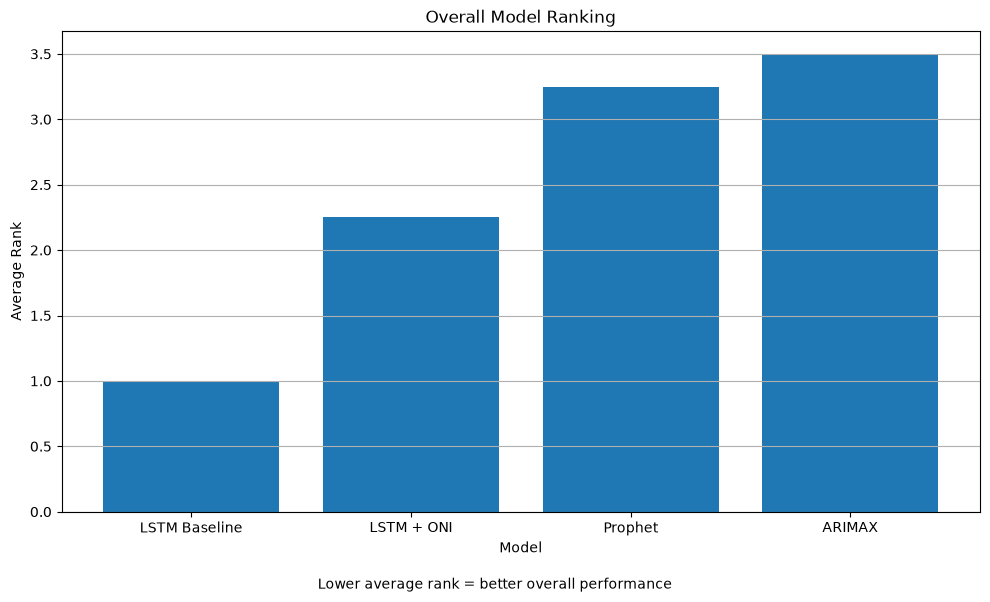

In [67]:
#Pictorial representation for ranking
#Overall model ranking based on average metric rank

plt.figure(figsize=(10, 6))

plt.bar(
    ranking["Model"],
    ranking["Average Rank"]
)

plt.xlabel("Model")
plt.ylabel("Average Rank")
plt.title("Overall Model Ranking")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.figtext(
    0.5, 0.01,
    "Lower average rank = better overall performance",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

In [68]:
#Final model comparison conclusion

best_model = ranking.iloc[0]["Model"]

print("FINAL MODEL COMPARISON")
print("=" * 40)

print(f"Best overall model: {best_model}")

print("\nPerformance summary:")
print(ranking[
    ["Model", "MAE", "RMSE", "sMAPE (%)", "MASE", "Average Rank"]
].to_string(index=False))

print("\nConclusion:")
print(
    f"{best_model} achieved the best overall performance "
    f"based on the lowest average rank across MAE, RMSE, sMAPE, and MASE."
)

FINAL MODEL COMPARISON
Best overall model: LSTM Baseline

Performance summary:
        Model      MAE     RMSE  sMAPE (%)     MASE  Average Rank
LSTM Baseline 1.316956 1.658211  44.185169 0.978711          1.00
   LSTM + ONI 4.201831 4.984564  90.559779 3.122639          2.25
      Prophet 4.524748 5.100074 103.685090 3.362619          3.25
       ARIMAX 5.116283 6.968454  86.691679 3.802225          3.50

Conclusion:
LSTM Baseline achieved the best overall performance based on the lowest average rank across MAE, RMSE, sMAPE, and MASE.


In [69]:
metrics_df.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)